In [46]:
import json

import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
import fasttext

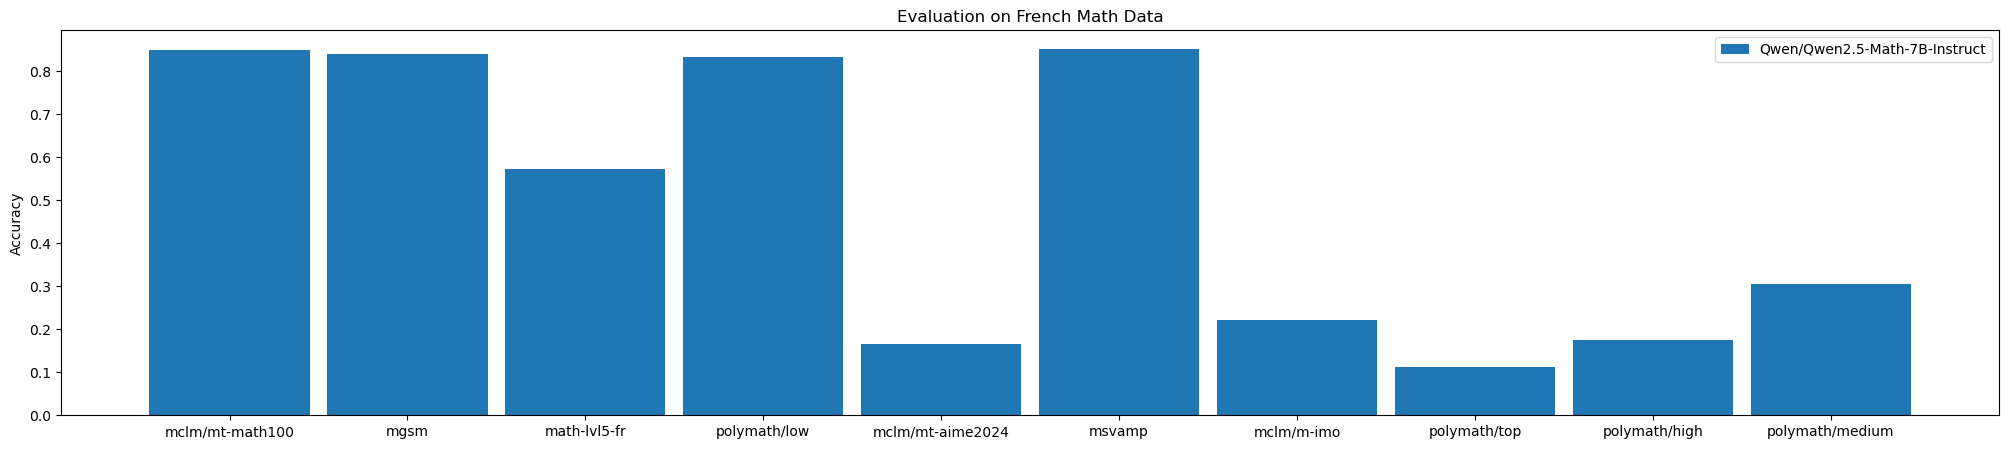

In [ ]:
with open("../eval.json", "r") as f:
    results = json.load(f)
    datasets = list(list(results.values())[0]["accuracies"].keys())
    n_models = len(results)

    fig, ax = plt.subplots(figsize=(25,5))
    for i, (model, result) in enumerate(results.items()):
        ax.bar(np.arange(len(datasets)) + (i-(0.5*(n_models-1)))/n_models, list(result["accuracies"].values()), width=0.9/n_models, label=model)

    ax.set_xticks(np.arange(len(datasets)))
    ax.set_xticklabels(datasets)
    ax.set_ylabel("Accuracy")
    ax.set_title("Evaluation on French Math Data")
    ax.legend()
    plt.show()

/home/gabriel/.cache/huggingface/hub/models--facebook--fasttext-language-identification/snapshots/3af127d4124fc58b75666f3594bb5143b9757e78/model.bin
mclm/mt-math100 : {'eng_Latn': 0.8902653615282039, 'kor_Hang': 0.02835070692337394, 'nld_Latn': 5.53143433232132e-05, 'yue_Hant': 0.017720877127320626, 'pcm_Latn': 2.1137802097581873e-05, 'hun_Latn': 0.0001365690882128988, 'glg_Latn': 4.1749140228888e-05, 'taq_Latn': 1.836283399365993e-06, 'bod_Tibt': 2.9277438112661582e-06, 'dan_Latn': 0.0012437711044148815, 'ita_Latn': 3.923341570741902e-06, 'hye_Armn': 8.171145504956708e-07, 'fur_Latn': 2.1306440972657216e-06, 'cat_Latn': 1.0092887378325969e-05, 'fra_Latn': 0.00012742917401324533, 'szl_Latn': 0.0001019801041393569, 'ron_Latn': 0.0005237539534014885, 'deu_Latn': 9.434158452833541e-05, 'dik_Latn': 0.0011568934929491294}


mgsm : {'eng_Latn': 0.9610396218299866, 'kor_Hang': 0.0030860634645505343, 'hun_Latn': 4.1586021921830255e-05, 'fra_Latn': 0.010817573445594463, 'nld_Latn': 0.00010294042049645214, 'ita_Latn': 4.999450458853971e-06, 'yue_Hant': 0.0004324925445689587, 'sot_Latn': 0.0034409300088882448, 'yor_Latn': 0.0027514898777008055, 'tsn_Latn': 0.0016772231757640839, 'deu_Latn': 2.2559828357771038e-06, 'bod_Tibt': 1.0085901485581416e-06, 'azb_Arab': 0.00011760104344284627, 'por_Latn': 1.5837270831980277e-05, 'dik_Latn': 3.261807141825557e-07, 'hye_Armn': 4.978305150871165e-08, 'pcm_Latn': 2.0747881244460587e-06, 'ind_Latn': 5.8880155847873536e-08, 'taq_Latn': 4.8678361054044216e-08, 'dan_Latn': 4.651148636185099e-06, 'ast_Latn': 1.7887330322992056e-06, 'glg_Latn': 1.6856285219546407e-07, 'est_Latn': 3.967577067669481e-07, 'oci_Latn': 0.00040496323024854066, 'hat_Latn': 0.00034799782373011115, 'tso_Latn': 1.3860538601875304e-06, 'sna_Latn': 0.008785608291625977, 'sun_Latn': 0.0008882550895214081, 'sr

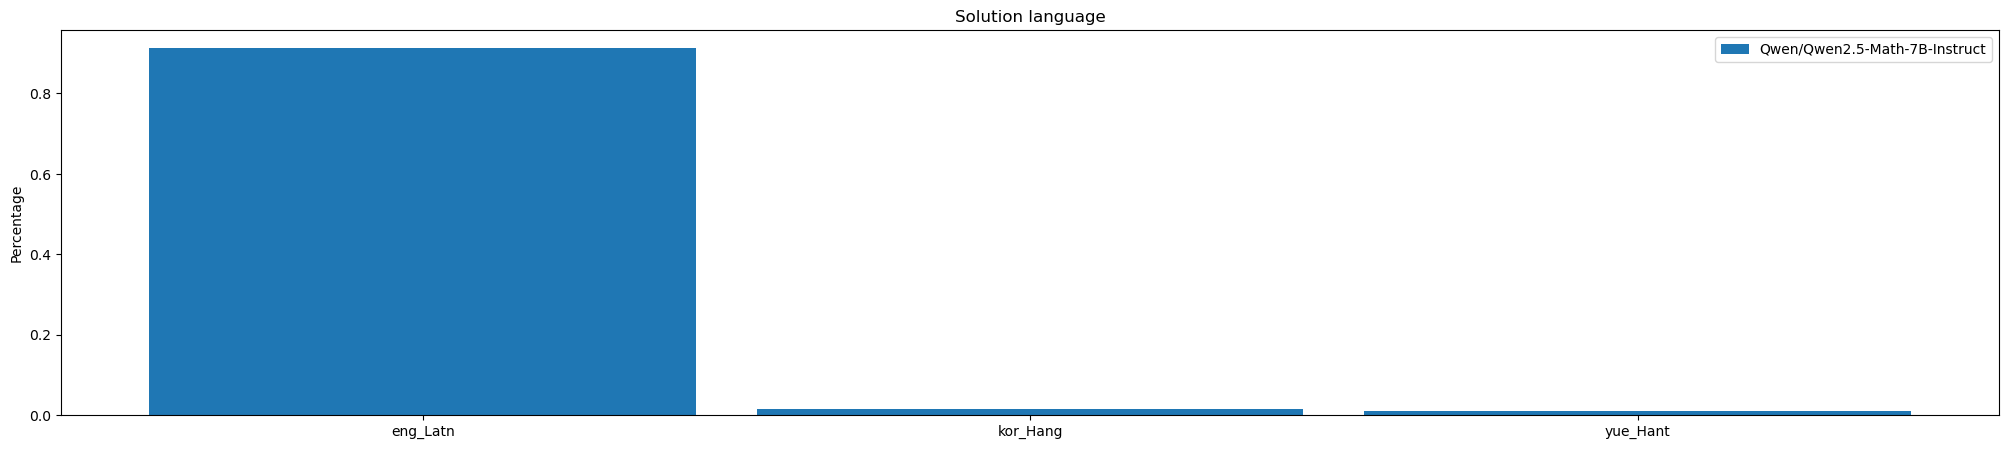

In [ ]:
model_path = hf_hub_download(repo_id="facebook/fasttext-language-identification", filename="model.bin")
print(model_path)
classifier = fasttext.load_model(model_path)

with open("../eval.json", "r") as f:
    results = json.load(f)
    datasets = list(list(results.values())[0]["accuracies"].keys())
    n_models = len(results)

    fig, ax = plt.subplots(figsize=(25,5))
    for i, (model, result) in enumerate(results.items()):
        languages = {}
        top_languages = {}
        for dataset in datasets:
            languages_dataset = {}
            for sample in result["samples"][dataset]:
                lang_pred = classifier.predict(sample["generation"].replace("\n", " "), k=3)
                for lang, prob in zip(lang_pred[0], lang_pred[1]):
                    lang = lang.split("__label__")[1]
                    if lang in languages_dataset:
                        languages_dataset[lang] += prob
                    else:
                        languages_dataset[lang] = prob
                    if lang in languages:
                        languages[lang] += prob
                    else:
                        languages[lang] = prob
            for lang in languages_dataset.keys():
                languages_dataset[lang] = languages_dataset[lang] / len(result["samples"][dataset])
            print(dataset, ":", languages_dataset)
        for lang in languages.keys():
            languages[lang] = languages[lang] / sum([len(result["samples"][dataset]) for dataset in datasets])
            if languages[lang] > 0.005:
                top_languages[lang] = languages[lang]

        ax.bar(np.arange(len(top_languages)) + (i-(0.5*(n_models-1)))/n_models, list(top_languages.values()), width=0.9/n_models, label=model)

    ax.set_xticks(np.arange(len(top_languages)))
    ax.set_xticklabels(top_languages)
    ax.set_ylabel("Percentage")
    ax.set_title("Solution language")
    ax.legend()
    plt.show()

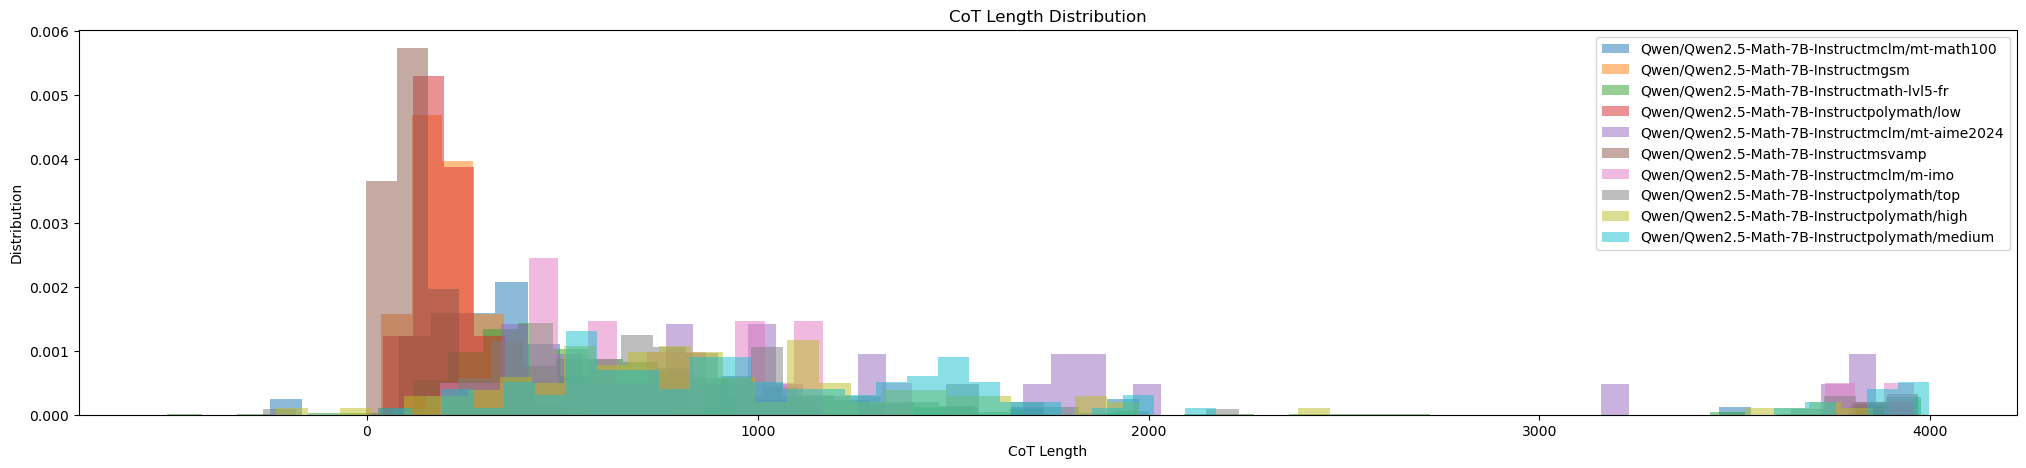

In [ ]:
with open("../eval.json", "r") as f:
    results = json.load(f)
    datasets = list(list(results.values())[0]["accuracies"].keys())
    n_models = len(results)

    for i, (model, result) in enumerate(results.items()):
        plt.figure(figsize=(25,5))
        for dataset in datasets:
            cot_lengths = []
            for sample in result["samples"][dataset]:
                cot_lengths.append(sample["cot_length"])

            plt.hist(cot_lengths, label=model+dataset, bins=50, density=True, alpha=0.5)
        plt.xlabel("CoT Length")
        plt.ylabel("Distribution")
        plt.title("CoT Length Distribution")
        plt.legend()
        plt.show()